Demand estimation and market analysis - air fryers

notebook 3 - costs, markups, and profit
role: pricing economist, using a demand model to reason about price, cost, and profitability

given the demand slope:
$$\hat{s}'_{bt}(p_{bt}) = \hat{\beta}_{\text{price}} \cdot s_{bt}(1 - s_{bt})$$


and the first order pricing condition
$$\hat{c}_{bt} = p_{bt} + \frac{s_{bt}}{\hat{s}'_{bt}(p_{bt})}$$

In [29]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='tab10')
COLORS = sns.color_palette('tab10', 10)
BRANDS = ['chefman','cosori','cuisinart','dash','gowise usa',
          'instant_pot','ninja','nuwave','oster','ultrean']
BRAND_PALETTE = {b: COLORS[i] for i, b in enumerate(BRANDS)}

df = pd.read_csv('air_fryers_clean_brand_year.csv')
char_cols = ['compact_share','dual_basket_share','oven_style_share','rotisserie_share','window_share']

# Re-run demand model
brand_dummies = pd.get_dummies(df['brand'], drop_first=True, prefix='brand').astype(float)
year_dummies  = pd.get_dummies(df['year'],  drop_first=True, prefix='year').astype(float)
X = pd.concat([df[['avg_price','avg_rating']+char_cols].astype(float),
               brand_dummies, year_dummies], axis=1)
X = sm.add_constant(X)
y = df['log_brand_share'].astype(float)
model = sm.OLS(y, X).fit()
print(f"Price coefficient: {model.params['avg_price']:.4f}  (negative = OK)")

# Compute cost and markup
df['demand_slope']  = model.params['avg_price'] * df['brand_share'] * (1 - df['brand_share'])
df['unit_cost']     = df['avg_price'] + df['brand_share'] / df['demand_slope']
df['markup']        = df['avg_price'] - df['unit_cost']
df['average_profit']= df['brand_share'] * df['markup']

print(df[['brand','year','avg_price','unit_cost','markup','average_profit']].round(2))


Price coefficient: -0.0377  (negative = OK)
          brand  year  avg_price  unit_cost  markup  average_profit
0       chefman  2019      72.96      44.23   28.73            2.18
1        cosori  2019     159.99     133.42   26.57            0.02
2     cuisinart  2019     229.47     199.73   29.74            3.19
3          dash  2019      55.18      22.00   33.17            6.63
4    gowise usa  2019      83.58      46.07   37.51           10.96
5   instant_pot  2019      78.02      51.05   26.97            0.43
6         ninja  2019     112.16      79.28   32.88            6.33
7        nuwave  2019     151.10     123.67   27.43            0.88
8         oster  2019     191.94     164.47   27.47            0.92
9       ultrean  2019      80.62      52.68   27.95            1.40
10      chefman  2020      97.43      69.24   28.19            1.64
11       cosori  2020     115.65      88.87   26.78            0.23
12    cuisinart  2020     227.91     198.35   29.57            3.02
13  

3.1: average unit costs and market ups by brand

In [27]:
tbl = df.groupby('brand')[['avg_price','unit_cost','markup','average_profit']].mean().round(2)
print(tbl)


             avg_price  unit_cost  markup  average_profit
brand                                                    
chefman          90.94      61.57   29.37            2.82
cosori          114.27      86.28   27.98            1.44
cuisinart       223.95     194.90   29.05            2.50
dash             57.48      27.94   29.54            2.99
gowise usa       87.45      56.30   31.15            4.61
instant_pot     104.46      71.90   32.56            6.01
ninja           145.34     112.49   32.85            6.31
nuwave          137.02     109.05   27.97            1.42
oster           189.03     161.80   27.23            0.68
ultrean          78.11      48.79   29.33            2.78


1. average unit costs and markups: Cuisinart and oster carry the highest inferred unit costs (194.90 and 161.80 respectively) consistent with their premium positioning. Dash has the lowest unit cost at 27.94 consistent with budget tier sourcing. Absolute dollar markups are relatively compressed across brands ranging from about 27$ to 33$ which is economically interesting given the wide price range.

2. Are any unit costs negative? No, all inferred unit costs are positive across all brand years. This is a reassuring sanity check that the model is behaving correctly.

3. Higher cost brands and ratings? Cuisinart and oster have the highest unit costs and they also tend to have decent but not exceptional ratings (around 4.4-4.5), suggesting that higher cost does not directly translate into standout consumer satisfaction. Ninja has high unit costs (112$) and is the market leader, suggesting its cost premium is offset by strong brand equity and product quality that drives share. Dash has low costs, low prices, and competitive ratings around 4.4, showing that budget products can still satisfy consumers well.

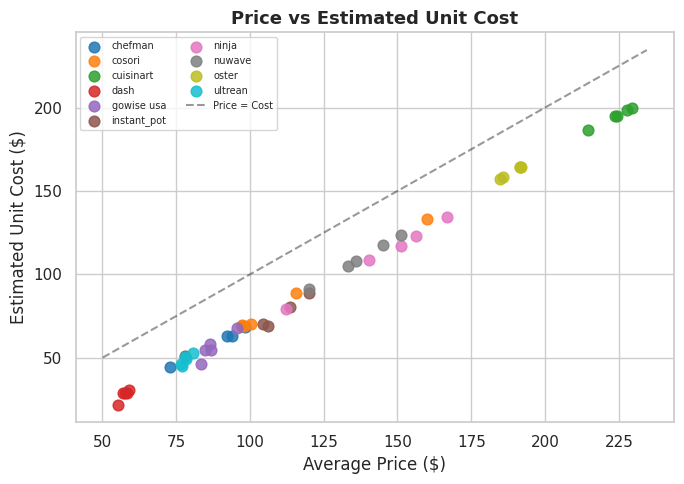

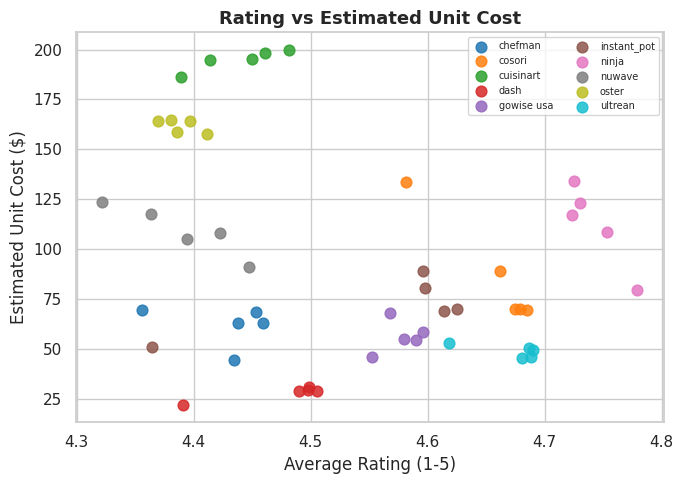

In [30]:
# Price vs Unit Cost
fig, ax = plt.subplots(figsize=(7,5))
for brand, grp in df.groupby('brand'):
    ax.scatter(grp['avg_price'], grp['unit_cost'], label=brand, color=BRAND_PALETTE[brand], s=60, alpha=0.85)
lo, hi = df['avg_price'].min()-5, df['avg_price'].max()+5
ax.plot([lo,hi],[lo,hi], 'k--', alpha=0.4, label='Price = Cost')
ax.set_xlabel('Average Price ($)'); ax.set_ylabel('Estimated Unit Cost ($)')
ax.set_title('Price vs Estimated Unit Cost', fontsize=13, fontweight='bold')
ax.legend(ncol=2, fontsize=7)
plt.tight_layout(); plt.show()

# Rating vs Unit Cost
fig, ax = plt.subplots(figsize=(7,5))
for brand, grp in df.groupby('brand'):
    ax.scatter(grp['avg_rating'], grp['unit_cost'], label=brand, color=BRAND_PALETTE[brand], s=60, alpha=0.85)
ax.set_xlabel('Average Rating (1-5)'); ax.set_ylabel('Estimated Unit Cost ($)')
ax.set_title('Rating vs Estimated Unit Cost', fontsize=13, fontweight='bold')
ax.legend(ncol=2, fontsize=7)
plt.tight_layout(); plt.show()


Do more expensive products have higher consumer satisfaction? the rating vs unit cost scatter shows not strong positive relationship between cost and satisfication. High cost brands like cuisinart and oster do not achieve notably higher ratings than cheaper brands like chefman or ultrean. This suggests that price in this market is driven more by product segment positioning and brand prestige than by quality differences that consumers perceive and rate. Ninja is an interesting case as it commands above average unit costs and above average ratings, making itthe brand that most strongly earns its premium in consumer perception.

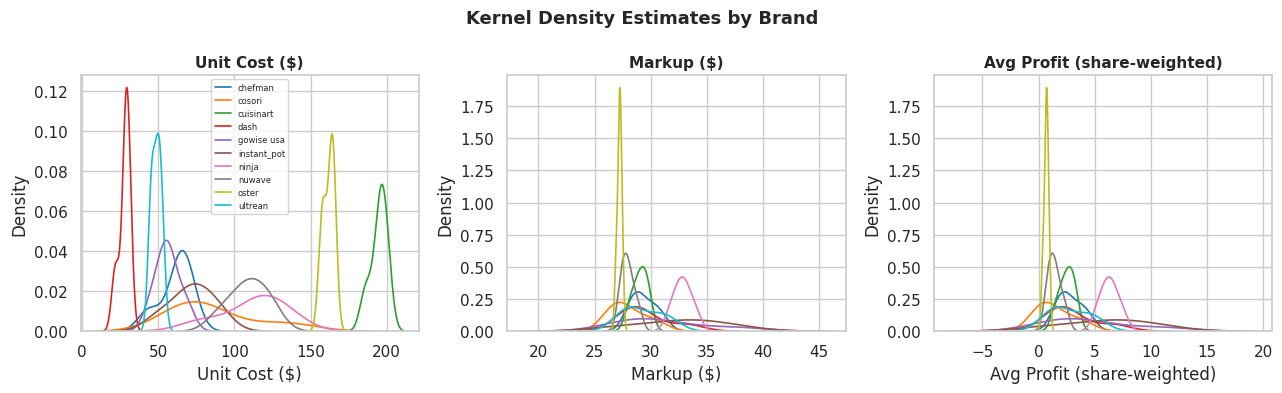

In [31]:
fig, axes = plt.subplots(1, 3, figsize=(13,4))
for brand, grp in df.groupby('brand'):
    c = BRAND_PALETTE[brand]
    sns.kdeplot(grp['unit_cost'],     ax=axes[0], label=brand, color=c, linewidth=1.2)
    sns.kdeplot(grp['markup'],        ax=axes[1], label=brand, color=c, linewidth=1.2)
    sns.kdeplot(grp['average_profit'],ax=axes[2], label=brand, color=c, linewidth=1.2)
for ax, t in zip(axes, ['Unit Cost ($)','Markup ($)','Avg Profit (share-weighted)']):
    ax.set_xlabel(t); ax.set_title(t, fontsize=11, fontweight='bold')
axes[0].legend(fontsize=6)
fig.suptitle('Kernel Density Estimates by Brand', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()


4. KDE interpretation: the unit cost distribution show clear seperation between budget brands (dash, ultrean clustered below 60), mid - tier brands ($60-$100), and premium brands (Cuisinart, oster above $150). The markup distributions are strikingly similar across brands, all clustered in the $27-$33 range, suggesting roughly uniform dollar markups across the market regardless of price tier. The average profit KDEs show much more seperation: ninja and instant pot have higher density mass at elevated profit values because their large market shares multiply out their moderate markups into much larger share weighted profit figures, while small share brands like oster and nuwave show compressed profit densities near zero.

 **3.4: average profit bar chart**

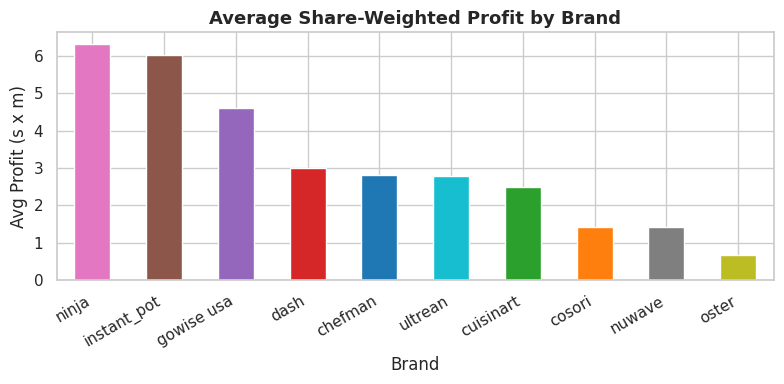

In [32]:
profit_by_brand = df.groupby('brand')['average_profit'].mean().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(8,4))
profit_by_brand.plot(kind='bar', ax=ax,
    color=[BRAND_PALETTE[b] for b in profit_by_brand.index])
ax.set_title('Average Share-Weighted Profit by Brand', fontsize=13, fontweight='bold')
ax.set_ylabel('Avg Profit (s x m)'); ax.set_xlabel('Brand')
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
plt.tight_layout(); plt.show()


**Brands with highest share weighted average profit**: ninja leads with an average profit index of 6.31 followed closely by instant pot at 6.01 and GoWise USA at 4.61. Ninja's dominance here is the result of combining a large and growing market share with above average markups around $33/ Oster is at the bottom with 0.68 which reflects its extremely small market share despite premium pricing: high prices and high costs leave it with adequate dollar margins but negligible share weighted profitability. the lesson for a potential market entrant or investor is that profitability in this market is driven more by sharethan by margin because dollar markups are compressed and fairly uniform across the field.